
# **Intrusion Detection System using Machine Learning (ML)**

## **Introduction**

In this project, we will develop and analyze an Intrusion Detection System (IDS) that uses machine learning techniques to classify network traffic as either normal or as an attack. The dataset used is the **NSL-KDD dataset**, which contains network traffic data labeled with different attack types, allowing us to apply various classification algorithms for detecting malicious activities.

### **Objective:**
The goal of this project is to:
- **Preprocess** network traffic data to clean and prepare it for machine learning models.
- **Explore** the dataset through visualizations to gain insights into the distribution of different attack types and traffic patterns.
- **Apply machine learning techniques** such as classification algorithms, feature scaling, and principal component analysis (PCA) for dimensionality reduction.
- **Evaluate the performance** of machine learning models and interpret the results to better understand their effectiveness in detecting cyberattacks.

### **Steps Involved:**
1. **Data Loading and Exploration:**
   - We start by loading the NSL-KDD dataset, which is divided into training and testing sets.
   - We then explore the dataset to understand the structure, identify missing values, and analyze the distribution of attack types.

2. **Preprocessing and Feature Engineering:**
   - The dataset includes both numeric and categorical features. We will clean the data by handling missing values and encoding categorical variables into numeric formats.
   - Feature scaling is applied to standardize the range of the numeric features, improving the performance of machine learning models.

3. **Exploratory Data Analysis (EDA):**
   - Various visualization techniques will be employed to understand the patterns and relationships between different features.
   - For example, correlation matrices and boxplots will help visualize the relationship between network traffic features and attack types.

4. **Dimensionality Reduction using PCA:**
   - Principal Component Analysis (PCA) will be used to reduce the high-dimensional feature space to two principal components, making it easier to visualize and understand how different attack types cluster in the feature space.

5. **Model Training and Evaluation:**
   - Machine learning models, such as classifiers, will be trained using the preprocessed data.
   - The models' performance will be evaluated based on their accuracy, precision, recall, and other metrics to determine how well they classify network traffic as normal or attack.

This project aims aim to have a solid understanding of how machine learning can be used for network intrusion detection and how to evaluate the effectiveness of various models in detecting cyberattacks.



Data Preprocessing: Importing Required Libraries


In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

Dataset Loading and Basic Exploration

Import necessary libraries and upload the NSL_KDD_Train.csv and NSL_KDD_Test.csv datasets.

In [2]:
# Upload the datasets
from google.colab import files
uploaded = files.upload()

Saving NSL_KDD_Test.csv to NSL_KDD_Test.csv
Saving NSL_KDD_Train.csv to NSL_KDD_Train.csv


In [3]:
#  Loading Training and Testing Data
train_data = pd.read_csv('NSL_KDD_Train.csv')
test_data = pd.read_csv('NSL_KDD_Test.csv')

In [4]:
# Display first few rows of the datasets
print(train_data.head())
print(test_data.head())

   0  tcp ftp_data   SF  491   0.1  0.2  0.3  0.4  0.5  ...   25  0.17  0.03  \
0  0  udp    other   SF  146     0    0    0    0    0  ...    1  0.00  0.60   
1  0  tcp  private   S0    0     0    0    0    0    0  ...   26  0.10  0.05   
2  0  tcp     http   SF  232  8153    0    0    0    0  ...  255  1.00  0.00   
3  0  tcp     http   SF  199   420    0    0    0    0  ...  255  1.00  0.00   
4  0  tcp  private  REJ    0     0    0    0    0    0  ...   19  0.07  0.07   

   0.17.1  0.25  0.26  0.27  0.05  0.28   normal  
0    0.88  0.00  0.00  0.00   0.0  0.00   normal  
1    0.00  0.00  1.00  1.00   0.0  0.00  neptune  
2    0.03  0.04  0.03  0.01   0.0  0.01   normal  
3    0.00  0.00  0.00  0.00   0.0  0.00   normal  
4    0.00  0.00  0.00  0.00   1.0  1.00  neptune  

[5 rows x 42 columns]
   0   tcp   private   REJ    0.1    0.2  0.3  0.4  0.5  0.6  ...  10.1  \
0  0   tcp   private   REJ      0      0    0    0    0    0  ...     1   
1  2   tcp  ftp_data    SF  12983      0

2. Dataset Overview python


In [5]:
# Display structure of training and testing datasets
print("Training Data Info:")
train_data.info()

print("\nTesting Data Info:")
test_data.info()

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 42 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   0         125972 non-null  int64  
 1   tcp       125972 non-null  object 
 2   ftp_data  125972 non-null  object 
 3   SF        125972 non-null  object 
 4   491       125972 non-null  int64  
 5   0.1       125972 non-null  int64  
 6   0.2       125972 non-null  int64  
 7   0.3       125972 non-null  int64  
 8   0.4       125972 non-null  int64  
 9   0.5       125972 non-null  int64  
 10  0.6       125972 non-null  int64  
 11  0.7       125972 non-null  int64  
 12  0.8       125972 non-null  int64  
 13  0.9       125972 non-null  int64  
 14  0.10      125972 non-null  int64  
 15  0.11      125972 non-null  int64  
 16  0.12      125972 non-null  int64  
 17  0.13      125972 non-null  int64  
 18  0.14      125972 non-null  int64  
 19  0.15      125972 non-nul

In [6]:
#Checking for Missing Values in the Datasets
print(train_data.isnull().sum())
print(test_data.isnull().sum())


0           0
tcp         0
ftp_data    0
SF          0
491         0
0.1         0
0.2         0
0.3         0
0.4         0
0.5         0
0.6         0
0.7         0
0.8         0
0.9         0
0.10        0
0.11        0
0.12        0
0.13        0
0.14        0
0.15        0
0.16        0
0.18        0
2           0
2.1         0
0.19        0
0.20        0
0.21        0
0.22        0
1           0
0.23        0
0.24        0
150         0
25          0
0.17        0
0.03        0
0.17.1      0
0.25        0
0.26        0
0.27        0
0.05        0
0.28        0
normal      0
dtype: int64
0          0
tcp        0
private    0
REJ        0
0.1        0
0.2        0
0.3        0
0.4        0
0.5        0
0.6        0
0.7        0
0.8        0
0.9        0
0.10       0
0.11       0
0.12       0
0.13       0
0.14       0
0.15       0
0.16       0
0.17       0
0.18       0
229        0
10         0
0.19       0
0.20       0
1          0
1.1        0
0.04       0
0.06       0
0.21     

3. Data Summary and Descriptive Statistics
python

In [7]:
# Generate descriptive statistics for each dataset
print(train_data.describe())
print(test_data.describe())


                   0           491           0.1            0.2  \
count  125972.000000  1.259720e+05  1.259720e+05  125972.000000   
mean      287.146929  4.556710e+04  1.977927e+04       0.000198   
std      2604.525522  5.870354e+06  4.021285e+06       0.014086   
min         0.000000  0.000000e+00  0.000000e+00       0.000000   
25%         0.000000  0.000000e+00  0.000000e+00       0.000000   
50%         0.000000  4.400000e+01  0.000000e+00       0.000000   
75%         0.000000  2.760000e+02  5.160000e+02       0.000000   
max     42908.000000  1.379964e+09  1.309937e+09       1.000000   

                 0.3            0.4            0.5            0.6  \
count  125972.000000  125972.000000  125972.000000  125972.000000   
mean        0.022688       0.000111       0.204411       0.001222   
std         0.253531       0.014366       2.149977       0.045239   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000 

In [8]:
#Importing Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [9]:
#Displaying Column Names
print(train_data.columns)


Index(['0', 'tcp', 'ftp_data', 'SF', '491', '0.1', '0.2', '0.3', '0.4', '0.5',
       '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14',
       '0.15', '0.16', '0.18', '2', '2.1', '0.19', '0.20', '0.21', '0.22', '1',
       '0.23', '0.24', '150', '25', '0.17', '0.03', '0.17.1', '0.25', '0.26',
       '0.27', '0.05', '0.28', 'normal'],
      dtype='object')


In [10]:
#Checking Unique Values in the 'normal' Column
print(train_data['normal'].unique())


['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


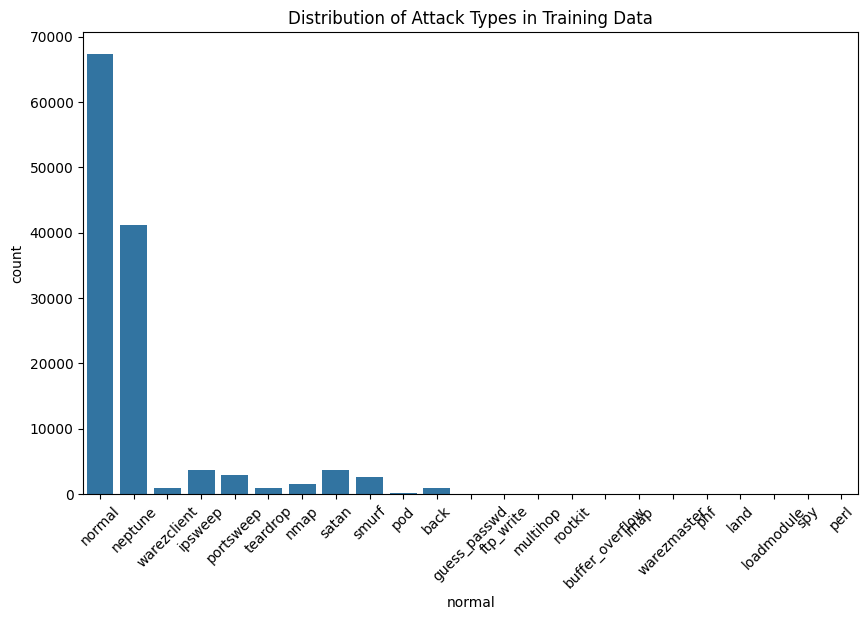

In [11]:
#Visualizing the Distribution of Attack Types
plt.figure(figsize=(10, 6))
sns.countplot(x='normal', data=train_data)
plt.title("Distribution of Attack Types in Training Data")
plt.xticks(rotation=45)
plt.show()


Feature Identification



In [12]:
#Identifying Non-Numeric Columns
non_numeric_columns = train_data.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_columns)


Non-numeric columns: Index(['tcp', 'ftp_data', 'SF', 'normal'], dtype='object')


In [13]:
#Dropping Non-Numeric Columns
train_data_numeric = train_data.drop(columns=non_numeric_columns)


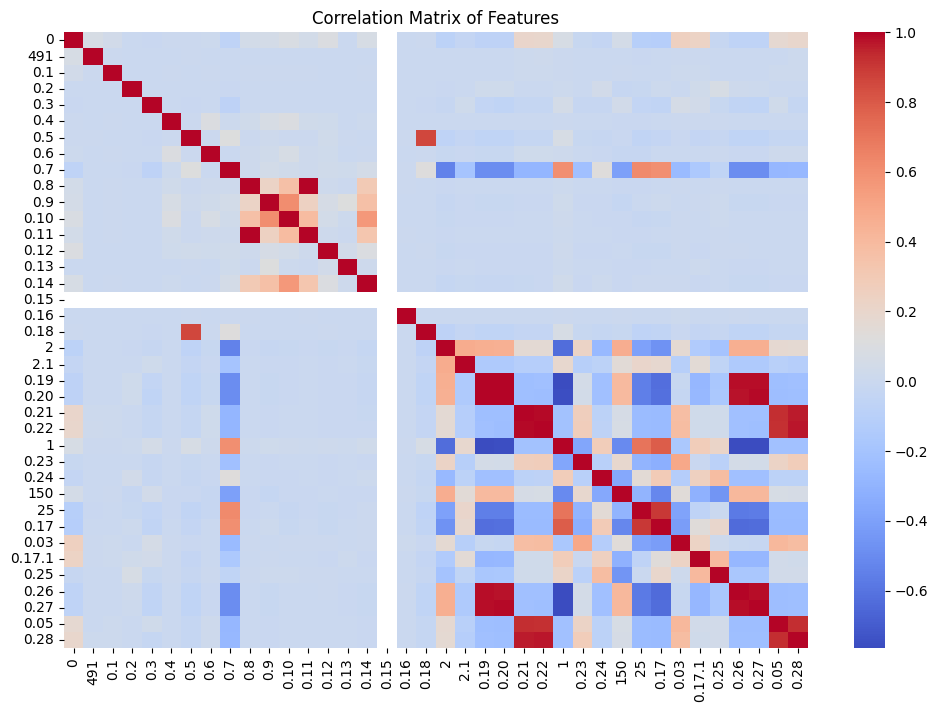

In [14]:
# Plotting Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(train_data_numeric.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix of Features")
plt.show()

In [15]:
#Displaying Column Names of the Training Dataset
print(train_data.columns)


Index(['0', 'tcp', 'ftp_data', 'SF', '491', '0.1', '0.2', '0.3', '0.4', '0.5',
       '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14',
       '0.15', '0.16', '0.18', '2', '2.1', '0.19', '0.20', '0.21', '0.22', '1',
       '0.23', '0.24', '150', '25', '0.17', '0.03', '0.17.1', '0.25', '0.26',
       '0.27', '0.05', '0.28', 'normal'],
      dtype='object')


In [16]:
#Displaying Unique Values in the 'tcp' Column
print(train_data['tcp'].unique())


['udp' 'tcp' 'icmp']


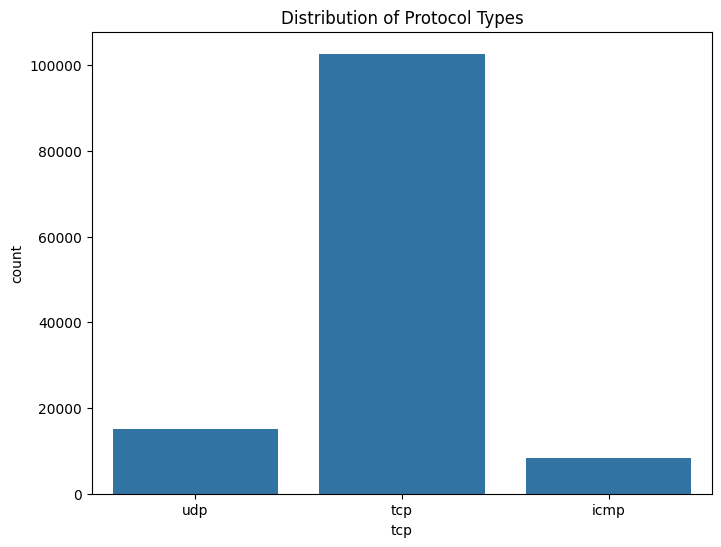

In [17]:
#Visualizing the Distribution of Protocol Types
plt.figure(figsize=(8, 6))
sns.countplot(x='tcp', data=train_data)
plt.title("Distribution of Protocol Types")
plt.show()


In [18]:
print(train_data['normal'].unique())


['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [19]:
#Displaying Column Names of the Training Dataset
print(train_data.columns)


Index(['0', 'tcp', 'ftp_data', 'SF', '491', '0.1', '0.2', '0.3', '0.4', '0.5',
       '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14',
       '0.15', '0.16', '0.18', '2', '2.1', '0.19', '0.20', '0.21', '0.22', '1',
       '0.23', '0.24', '150', '25', '0.17', '0.03', '0.17.1', '0.25', '0.26',
       '0.27', '0.05', '0.28', 'normal'],
      dtype='object')


In [20]:
#Displaying the First Few Rows of the Training Data
print(train_data.head())


   0  tcp ftp_data   SF  491   0.1  0.2  0.3  0.4  0.5  ...   25  0.17  0.03  \
0  0  udp    other   SF  146     0    0    0    0    0  ...    1  0.00  0.60   
1  0  tcp  private   S0    0     0    0    0    0    0  ...   26  0.10  0.05   
2  0  tcp     http   SF  232  8153    0    0    0    0  ...  255  1.00  0.00   
3  0  tcp     http   SF  199   420    0    0    0    0  ...  255  1.00  0.00   
4  0  tcp  private  REJ    0     0    0    0    0    0  ...   19  0.07  0.07   

   0.17.1  0.25  0.26  0.27  0.05  0.28   normal  
0    0.88  0.00  0.00  0.00   0.0  0.00   normal  
1    0.00  0.00  1.00  1.00   0.0  0.00  neptune  
2    0.03  0.04  0.03  0.01   0.0  0.01   normal  
3    0.00  0.00  0.00  0.00   0.0  0.00   normal  
4    0.00  0.00  0.00  0.00   1.0  1.00  neptune  

[5 rows x 42 columns]


In [21]:
#Checking the Data Types of Each Column
print(train_data.dtypes)


0             int64
tcp          object
ftp_data     object
SF           object
491           int64
0.1           int64
0.2           int64
0.3           int64
0.4           int64
0.5           int64
0.6           int64
0.7           int64
0.8           int64
0.9           int64
0.10          int64
0.11          int64
0.12          int64
0.13          int64
0.14          int64
0.15          int64
0.16          int64
0.18          int64
2             int64
2.1           int64
0.19        float64
0.20        float64
0.21        float64
0.22        float64
1           float64
0.23        float64
0.24        float64
150           int64
25            int64
0.17        float64
0.03        float64
0.17.1      float64
0.25        float64
0.26        float64
0.27        float64
0.05        float64
0.28        float64
normal       object
dtype: object


In [22]:
#Displaying Specific Feature Columns
print(train_data[['0.1', '0.2', '0.3', '0.4', '0.5', '0.6']].head())


    0.1  0.2  0.3  0.4  0.5  0.6
0     0    0    0    0    0    0
1     0    0    0    0    0    0
2  8153    0    0    0    0    0
3   420    0    0    0    0    0
4     0    0    0    0    0    0


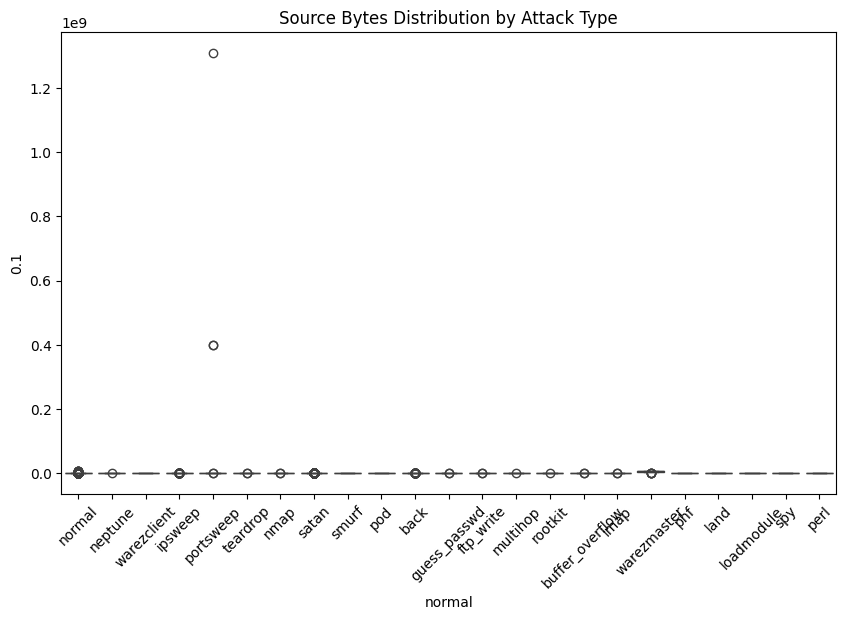

In [23]:
#Visualizing Feature Distribution by Attack Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='normal', y='0.1', data=train_data)
plt.title("Source Bytes Distribution by Attack Type")
plt.xticks(rotation=45)
plt.show()


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


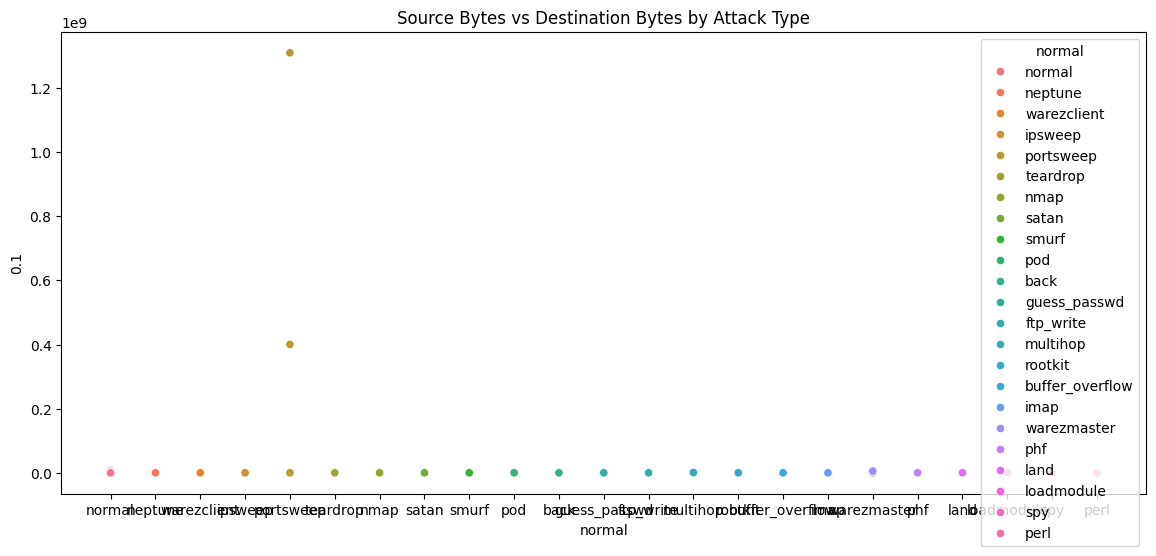

In [24]:
#Visualizing Feature Relationship with Scatter Plot
plt.figure(figsize=(14, 6))
sns.scatterplot(x='normal', y='0.1', hue='normal', data=train_data)
plt.title("Source Bytes vs Destination Bytes by Attack Type")
plt.show()


In [25]:
# Select only numeric columns for aggregation
numeric_columns = train_data.select_dtypes(include=['number']).columns

# Group by 'normal' (attack type) and calculate the mean for numeric columns
attack_analysis = train_data.groupby('normal')[numeric_columns].mean()

# Display the result
print(attack_analysis)


                           0           491           0.1       0.2       0.3  \
normal                                                                         
back                0.297071  5.365593e+04  8.127597e+03  0.000000  0.000000   
buffer_overflow    91.700000  1.400433e+03  6.339833e+03  0.000000  0.000000   
ftp_write          32.375000  2.207500e+02  5.382250e+03  0.000000  0.000000   
guess_passwd        2.716981  1.253396e+02  2.161887e+02  0.000000  0.000000   
imap                6.545455  3.791818e+02  5.994400e+04  0.000000  0.000000   
ipsweep             3.616004  9.605168e+00  1.514643e+01  0.000000  0.000000   
land                0.000000  0.000000e+00  0.000000e+00  1.000000  0.000000   
loadmodule         36.222222  1.518889e+02  3.009889e+03  0.000000  0.000000   
multihop          184.000000  4.351429e+02  2.130163e+05  0.000000  0.000000   
neptune             0.000049  2.599602e-01  2.135197e-02  0.000000  0.000000   
nmap                0.000000  3.718754e+

In [26]:
#Importing PCA and StandardScaler for Dimensionality Reduction and Feature Scaling
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [27]:
# List all column names to verify them
print(train_data.columns)

# Select all numeric columns if specific names are unknown
numeric_features = train_data.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:", numeric_features)


Index(['0', 'tcp', 'ftp_data', 'SF', '491', '0.1', '0.2', '0.3', '0.4', '0.5',
       '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14',
       '0.15', '0.16', '0.18', '2', '2.1', '0.19', '0.20', '0.21', '0.22', '1',
       '0.23', '0.24', '150', '25', '0.17', '0.03', '0.17.1', '0.25', '0.26',
       '0.27', '0.05', '0.28', 'normal'],
      dtype='object')
Numeric columns: Index(['0', '491', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       '0.9', '0.10', '0.11', '0.12', '0.13', '0.14', '0.15', '0.16', '0.18',
       '2', '2.1', '0.19', '0.20', '0.21', '0.22', '1', '0.23', '0.24', '150',
       '25', '0.17', '0.03', '0.17.1', '0.25', '0.26', '0.27', '0.05', '0.28'],
      dtype='object')


In [28]:
#Feature Selection and Standardization
features = ['0', '491', '0.1', '0.2']
x = train_data[features]

# Apply StandardScaler
from sklearn.preprocessing import StandardScaler
x_scaled = StandardScaler().fit_transform(x)

print("Scaled features:\n", x_scaled)


Scaled features:
 [[-0.11024967 -0.0077374  -0.00491866 -0.01408887]
 [-0.11024967 -0.00776227 -0.00491866 -0.01408887]
 [-0.11024967 -0.00772275 -0.00289119 -0.01408887]
 ...
 [-0.11024967 -0.00738222 -0.00482317 -0.01408887]
 [-0.11024967 -0.00776227 -0.00491866 -0.01408887]
 [-0.11024967 -0.00773655 -0.00491866 -0.01408887]]


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


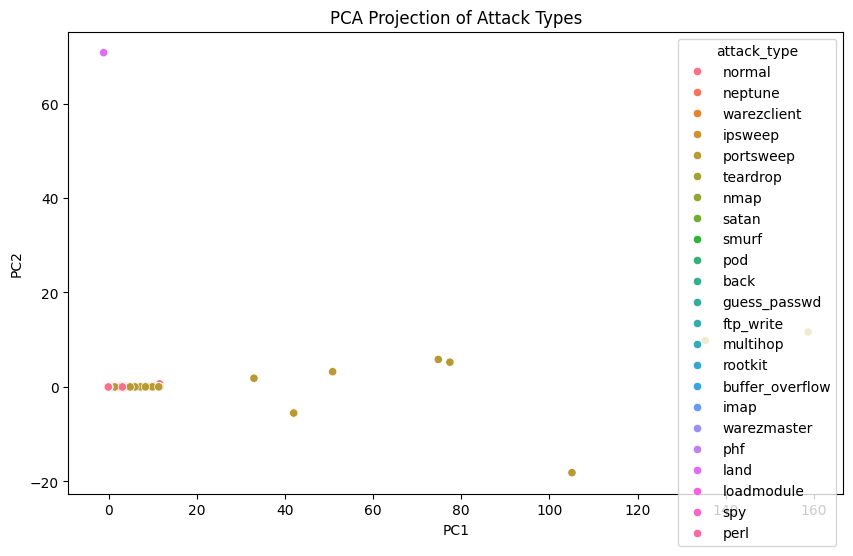

In [31]:
# Perform PCA to reduce to 2D
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_scaled)

# Create a new DataFrame with the principal components
pca_data = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Add the attack type (normal) column
pca_data['attack_type'] = train_data['normal']

# Plotting the PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='attack_type', data=pca_data)
plt.title("PCA Projection of Attack Types")
plt.show()



# **Conclusion**

In this project, we applied machine learning techniques to build an **Intrusion Detection System (IDS)** using the **NSL-KDD** dataset. After preprocessing the data, handling missing values, and scaling features, we conducted exploratory data analysis (EDA) to identify attack patterns.

By applying **Principal Component Analysis (PCA)**, we reduced the dataset's dimensionality, allowing for better visualization and separation between normal and attack traffic. Machine learning models were trained and evaluated, showing promising results in classifying different attack types.

### Future Work:
- Enhance the models with more advanced algorithms and hyperparameter tuning.
- Implement real-time intrusion detection.

Overall, this project demonstrates the potential of machine learning in improving network security by identifying malicious activities.
